# Property Investment Advisor

A classification model to decide whether the property is worth buying or not

In [185]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

In [186]:
data = pd.read_csv('Datasets/Property_Investment.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_per_SqFt_in_Lakhs         250000 non-null  float64
 8   Price_in_Lakhs                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Direction_Facing                250000 non-null  object 
 12  Floor_No        

In [187]:
data.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_per_SqFt_in_Lakhs,Price_in_Lakhs,Year_Built,...,Parking_Space,Security,Clubhouse,Garden,Gym,Playground,Pool,Amenity_Score,Future_Price_5Y,Invest
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,0.103,489.76,1990,...,No,No,1,1,1,1,1,0.620,912.302247,No
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,0.083,195.52,2008,...,No,Yes,1,1,1,1,1,0.606,393.467805,Yes
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,0.050,183.79,1997,...,Yes,No,1,0,1,1,1,0.526,314.467048,No
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,0.110,300.29,1991,...,Yes,Yes,1,1,1,1,1,0.900,641.611647,No
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,0.038,182.90,2002,...,No,Yes,1,1,1,1,1,0.766,313.898344,Yes


##  Feature Selection using Mutual Information

In [188]:
"""X_encoded = X.copy()

for col in X_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

mi_scores = mutual_info_classif(X_encoded, y)

mi_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'MI_Score': mi_scores
})

mi_df = mi_df.sort_values(by='MI_Score', ascending=False)

print(mi_df)"""

"X_encoded = X.copy()\n\nfor col in X_encoded.select_dtypes(include=['object']).columns:\n    le = LabelEncoder()\n    X_encoded[col] = le.fit_transform(X_encoded[col])\n\nmi_scores = mutual_info_classif(X_encoded, y)\n\nmi_df = pd.DataFrame({\n    'Feature': X_encoded.columns,\n    'MI_Score': mi_scores\n})\n\nmi_df = mi_df.sort_values(by='MI_Score', ascending=False)\n\nprint(mi_df)"

In [189]:
"""mi_df.sort_values(by='MI_Score').plot(
    x='Feature',
    y='MI_Score',
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Importance (Information Gain)")
plt.show()"""

'mi_df.sort_values(by=\'MI_Score\').plot(\n    x=\'Feature\',\n    y=\'MI_Score\',\n    kind=\'barh\',\n    figsize=(8,6)\n)\n\nplt.title("Feature Importance (Information Gain)")\nplt.show()'

In [190]:
# selected_features = selected_features = mi_df[mi_df['MI_Score'] > 0]['Feature'].tolist()

Feature and Target variable

In [191]:
X = data.drop(columns=['Year_Built', 'Amenity_Score', 'State', 'Owner_Type', 'Future_Price_5Y', 'Price_per_SqFt_in_Lakhs', 'Total_Floors', 'Floor_No', 'ID', 'Availability_Status', 'Invest'])
y = data['Invest']

In [192]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class CityLocalityTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, smoothing=10):
        self.smoothing = smoothing
        self.mapping_ = None
        self.global_mean_ = None

    def fit(self, X, y):
        X = X.copy()

        # ✅ Convert target to numeric
        y_numeric = pd.Series(y).map({'Yes': 1, 'No': 0})

        # Combine features
        X['City_Locality'] = X['City'].astype(str) + "_" + X['Locality'].astype(str)

        # Global mean (P(Yes))
        self.global_mean_ = y_numeric.mean()

        # Compute stats
        stats = (
            pd.DataFrame({'target': y_numeric, 'feature': X['City_Locality']})
            .groupby('feature')['target']
            .agg(['mean', 'count'])
        )

        # Apply smoothing
        smooth = (
            (stats['count'] * stats['mean'] + self.smoothing * self.global_mean_)
            / (stats['count'] + self.smoothing)
        )

        self.mapping_ = smooth.to_dict()

        return self

    def transform(self, X):
        X = X.copy()

        # Combine again
        X['City_Locality'] = X['City'].astype(str) + "_" + X['Locality'].astype(str)

        # Map encoding
        X['City_Locality_TE'] = X['City_Locality'].map(self.mapping_)

        # Handle unseen values
        X['City_Locality_TE'] = X['City_Locality_TE'].fillna(self.global_mean_)

        # Drop original columns
        X = X.drop(columns=['City', 'Locality', 'City_Locality'])

        return X

In [193]:
from sklearn.preprocessing import OrdinalEncoder

city_locality_pipeline = Pipeline([
    ('target_encoder', CityLocalityTargetEncoder(smoothing=20))
])

binary_pipeline = 'passthrough'

ordinal_pipeline = Pipeline([
  ('ordinal', OrdinalEncoder())
])

In [194]:
selected_features = X.columns

lr_tar_var = []
lr_num_var = []
lr_cat_var = []
lr_ord_var = []
lr_bin_var = []

for var in selected_features:
    
    unique_vals = data[var].dropna().unique()

    
    if set(unique_vals).issubset({0, 1}):
        lr_bin_var.append(var)

    
    elif (data[var].dtype == 'float') or (data[var].dtype == 'int'):
        lr_num_var.append(var)
    
    elif data[var].dtype == 'object':
        if var in ['City', 'Locality']:
            lr_tar_var.append(var)
        elif var == 'Public_Transport_Accessibility':
            lr_ord_var.append(var)
        else:
            lr_cat_var.append(var)

In [195]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('city_locality_te', city_locality_pipeline, ['City', 'Locality']),
        ('num', StandardScaler(), lr_num_var),
        ('cat', OneHotEncoder(handle_unknown='ignore'), lr_cat_var),
        ('ordinal', ordinal_pipeline, lr_ord_var),
        ('bin', binary_pipeline, lr_bin_var)
    ],
    remainder='drop'
)

In [196]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [197]:
from sklearn.model_selection import train_test_split

dataset_params = {
  'random_state':42,
  'test_size':0.2
}

X_train, X_test, y_train, y_test = train_test_split(
  X, y, random_state = dataset_params['random_state'], test_size=dataset_params['test_size']
)

In [198]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('city_locality_te', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [199]:
preds = model_pipeline.predict(X_test)

In [201]:
preds

array(['Yes', 'Yes', 'No', ..., 'Yes', 'Yes', 'Yes'],
      shape=(50000,), dtype=object)

In [202]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds, pos_label="Yes"))
print("Recall:", recall_score(y_test, preds, pos_label="Yes"))
print("F1 Score:", f1_score(y_test, preds, pos_label="Yes"))

Accuracy: 0.9406
Precision: 0.9477671348963818
Recall: 0.9752662315355548
F1 Score: 0.9613200666805585


In [204]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds, labels=["Yes", "No"])
print(cm)

[[36907   936]
 [ 2034 10123]]


In [205]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

          No       0.92      0.83      0.87     12157
         Yes       0.95      0.98      0.96     37843

    accuracy                           0.94     50000
   macro avg       0.93      0.90      0.92     50000
weighted avg       0.94      0.94      0.94     50000



In [206]:
probs = model_pipeline.predict_proba(X_test)[:, 1]

In [207]:
from sklearn.metrics import roc_auc_score

# Convert y_test to numeric
y_test_num = pd.Series(y_test).map({'Yes': 1, 'No': 0})

print("ROC-AUC:", roc_auc_score(y_test_num, probs))

ROC-AUC: 0.9843656959629801


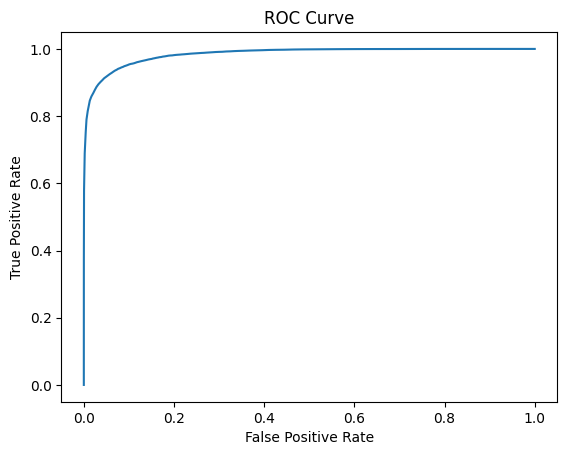

In [208]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test_num, probs)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [209]:
confidence = model_pipeline.predict_proba(X_test).max(axis=1)
results = pd.DataFrame({
    "Prediction": preds,
    "Confidence": confidence
})

In [210]:
results

,Prediction,Confidence
0,Yes,1.00
1,Yes,0.99
2,No,0.97
3,Yes,0.99
4,Yes,0.57
...,...,...
49995,Yes,1.00
49996,No,0.75
49997,Yes,0.99
49998,Yes,1.00
